In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)

pd.set_option("display.max_columns", None)

In [6]:
df = pd.read_csv(r"C:\Users\kunja\Downloads\Ecommerce_Vector_RAG\data\processed\amazon_products_clean.csv")

df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,review_title,review_content,combined_text
0,B07JW9H4J1,wayona nylon braided usb to lightning fast cha...,computers accessories accessories peripherals ...,399.0,1099.0,64%,4.2,24269,high compatibility compatible with iphone 12 1...,satisfied charging is really fast value for mo...,looks durable charging is fine toono complains...,wayona nylon braided usb to lightning fast cha...
1,B098NS6PVG,ambrane unbreakable 60w 3a fast charging 1 5m ...,computers accessories accessories peripherals ...,199.0,349.0,43%,4.0,43994,compatible with all type c enabled devices be ...,a good braided cable for your type c device go...,i ordered this cable to connect my phone to an...,ambrane unbreakable 60w 3a fast charging 1 5m ...
2,B096MSW6CT,sounce fast phone charging cable data sync usb...,computers accessories accessories peripherals ...,199.0,1899.0,90%,3.9,7928,fast charger data sync with built in safety pr...,good speed for earlier versions good product w...,not quite durable and sturdy https m media ama...,sounce fast phone charging cable data sync usb...
3,B08HDJ86NZ,boat deuce usb 300 2 in 1 type c micro usb str...,computers accessories accessories peripherals ...,329.0,699.0,53%,4.2,94363,the boat deuce usb 300 2 in 1 cable is compati...,good product good one nice really nice product...,good product long wire charges good nice i bou...,boat deuce usb 300 2 in 1 type c micro usb str...
4,B08CF3B7N1,portronics konnect l 1 2m fast charging 3a 8 p...,computers accessories accessories peripherals ...,154.0,399.0,61%,4.2,16905,charge sync function this cable comes with cha...,as good as original decent good one for second...,bought this instead of original apple does the...,portronics konnect l 1 2m fast charging 3a 8 p...


In [7]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1397
Columns : 12


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1397 entries, 0 to 1396
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1397 non-null   object 
 1   product_name         1397 non-null   object 
 2   category             1397 non-null   object 
 3   discounted_price     1397 non-null   float64
 4   actual_price         1397 non-null   float64
 5   discount_percentage  1397 non-null   object 
 6   rating               1397 non-null   float64
 7   rating_count         1397 non-null   int64  
 8   about_product        1397 non-null   object 
 9   review_title         1397 non-null   object 
 10  review_content       1397 non-null   object 
 11  combined_text        1397 non-null   object 
dtypes: float64(3), int64(1), object(8)
memory usage: 131.1+ KB


In [9]:
df.describe()

,discounted_price,actual_price,rating,rating_count
count,1397.000000,1397.000000,1397.000000,1397.000000
mean,3234.884610,5622.504853,4.093486,18521.919828
std,7075.647836,11074.560205,0.291831,43533.648274
min,39.000000,39.000000,2.000000,2.000000
25%,347.000000,899.000000,4.000000,1191.000000
50%,850.000000,1699.000000,4.100000,5137.000000
75%,2095.000000,4650.000000,4.300000,17415.000000
max,77990.000000,139900.000000,5.000000,426973.000000


In [10]:
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
review_title           0
review_content         0
combined_text          0
dtype: int64

In [11]:
df["category"].value_counts().head(15)

category
computers accessories accessories peripherals cables accessories cables usbcables                        183
electronics wearabletechnology smartwatches                                                               76
electronics mobiles accessories smartphones basicmobiles smartphones                                      68
electronics hometheater tv video televisions smarttelevisions                                             61
electronics headphones earbuds accessories headphones in ear                                              52
electronics hometheater tv video accessories remotecontrols                                               49
home kitchen kitchen homeappliances smallkitchenappliances mixergrinders                                  27
home kitchen kitchen homeappliances vacuum cleaning ironing irons steamers accessories irons dryirons     24
computers accessories accessories peripherals keyboards mice inputdevices mice                            24
home kitch

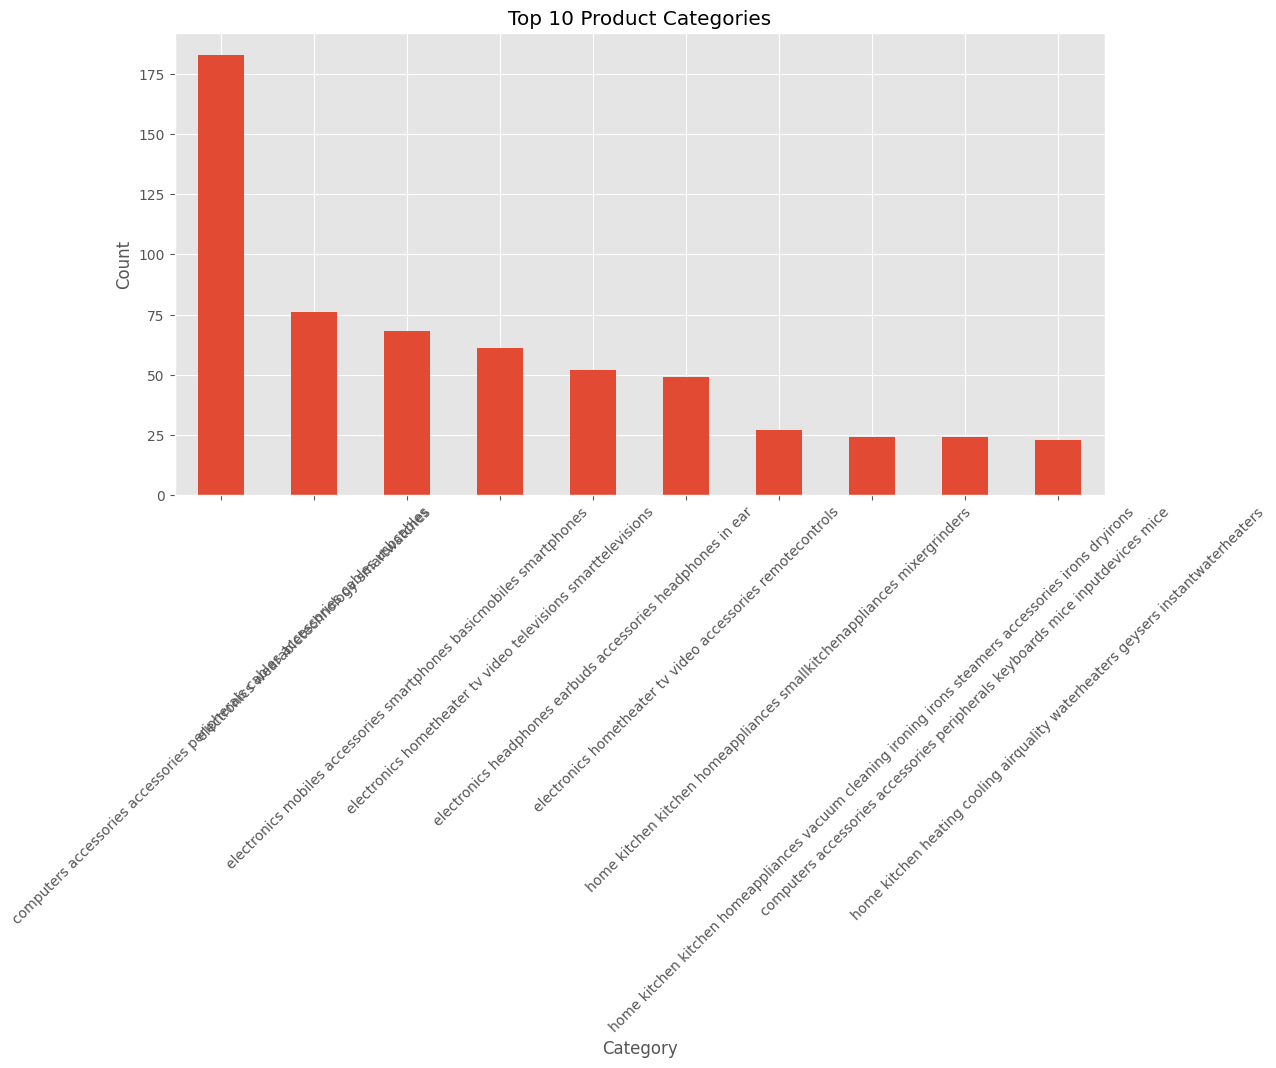

In [12]:
top_categories = df["category"].value_counts().head(10)

plt.figure(figsize=(12,6))
top_categories.plot(kind="bar")

plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

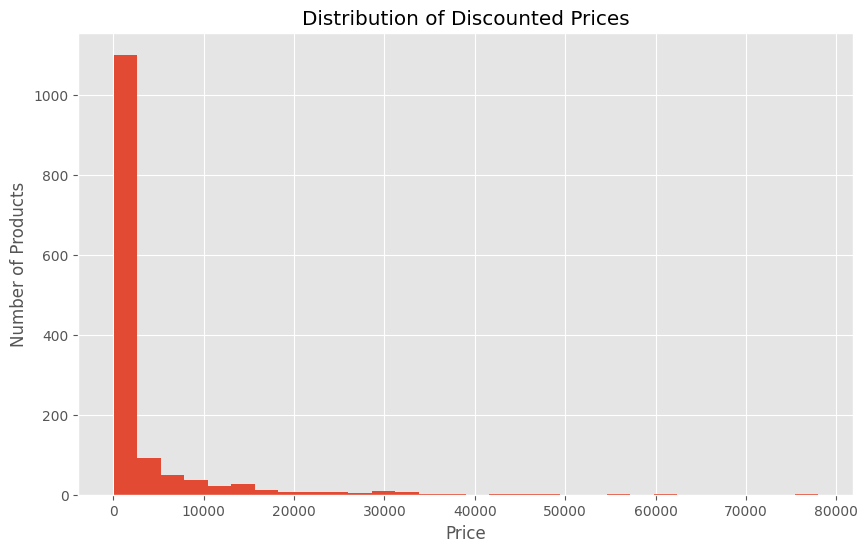

In [13]:
plt.figure(figsize=(10,6))

plt.hist(df["discounted_price"], bins=30)

plt.title("Distribution of Discounted Prices")
plt.xlabel("Price")
plt.ylabel("Number of Products")

plt.show()

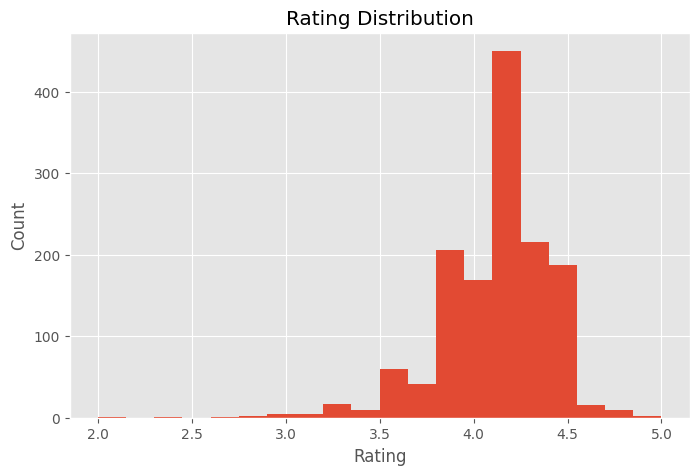

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df["rating"], bins=20)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

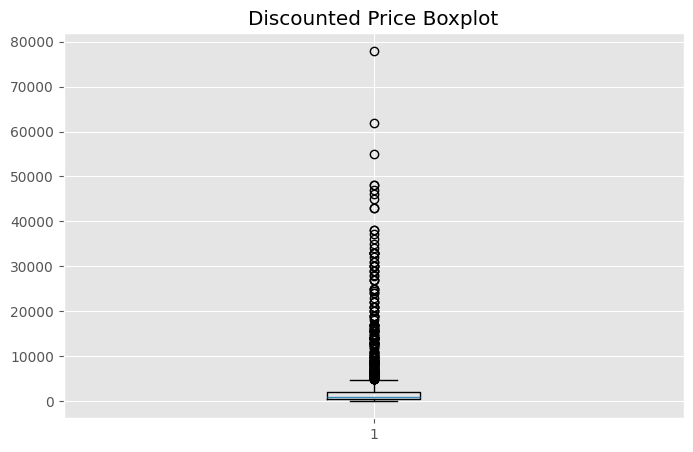

In [15]:
plt.figure(figsize=(8,5))

plt.boxplot(df["discounted_price"])

plt.title("Discounted Price Boxplot")

plt.show()

In [16]:
df[
    ["product_name",
     "rating"]
].sort_values(
    by="rating",
    ascending=False
).head(10)

,product_name,rating
174,syncwire ltg to usb cable for fast charging co...,5.0
739,amazon basics wireless mouse 2 4 ghz connectio...,5.0
1078,swiffer instant electric water heater faucet t...,4.8
1134,oratech coffee frother electric milk frother e...,4.8
1231,instant pot air fryer vortex 2qt touch control...,4.8
249,sony bravia 164 cm 65 inches 4k ultra hd smart...,4.7
1156,figment handheld milk frother rechargeable 3 s...,4.7
1159,zuvexa usb rechargeable electric foam maker ha...,4.7
1320,campfire spring chef prolix instant portable w...,4.7
1208,multifunctional 2 in 1 electric egg boiling st...,4.7


In [17]:
df[
    ["product_name",
     "discounted_price"]
].sort_values(
    by="discounted_price",
    ascending=False
).head(10)

,product_name,discounted_price
249,sony bravia 164 cm 65 inches 4k ultra hd smart...,77990.0
323,oneplus 163 8 cm 65 inches u series 4k led sma...,61999.0
255,vu 164 cm 65 inches the gloled series 4k smart...,54990.0
282,lg 139 cm 55 inches 4k ultra hd smart led tv 5...,47990.0
192,samsung 138 cm 55 inches crystal 4k neo series...,47990.0
330,mi 138 8 cm 55 inches 5x series 4k ultra hd le...,46999.0
276,samsung 138 cm 55 inches crystal 4k series ult...,45999.0
523,oneplus 10t 5g moonstone black 8gb ram 128gb s...,44999.0
216,oneplus 138 7 cm 55 inches u series 4k led sma...,42999.0
1286,lg 1 5 ton 5 star ai dual inverter split ac co...,42990.0


In [18]:
df[
    ["product_name",
     "discounted_price"]
].sort_values(
    by="discounted_price"
).head(10)

,product_name,discounted_price
918,e cosmos 5v 1 2w portable flexible usb led lig...,39.00
626,gizga essentials universal silicone keyboard p...,39.00
936,inventis 5v 1 2w portable flexible usb led lig...,39.00
602,classmate octane neon blue gel pens pack of 5 ...,50.00
178,flix beetel flow usb to micro usb pvc data syn...,57.89
470,flix micro usb cable for smartphone black,59.00
44,flix beetel usb to micro usb pvc data sync 2a ...,59.00
684,e cosmos 5v 1 2w portable flexible usb led lig...,59.00
23,flix micro usb cable for smartphone black,59.00
773,classmate pulse spiral notebook 240 mm x 180 m...,67.00


In [19]:
numeric_columns = [
    "discounted_price",
    "actual_price",
    "rating",
    "rating_count"
]

corr = df[numeric_columns].corr()

corr

,discounted_price,actual_price,rating,rating_count
discounted_price,1.000000,0.961575,0.124900,-0.029062
actual_price,0.961575,1.000000,0.125992,-0.037947
rating,0.124900,0.125992,1.000000,0.104469
rating_count,-0.029062,-0.037947,0.104469,1.000000


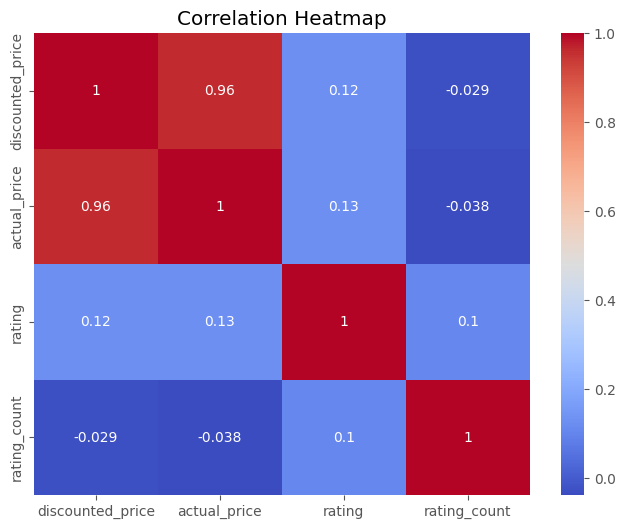

In [20]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [21]:
df["discount_amount"] = (
    df["actual_price"]
    - df["discounted_price"]
)

In [22]:
df[
    ["product_name",
     "discount_amount"]
].sort_values(
    by="discount_amount",
    ascending=False
).head(10)

,product_name,discount_amount
249,sony bravia 164 cm 65 inches 4k ultra hd smart...,61910.0
1115,coway professional air purifier for home longe...,45500.0
556,samsung galaxy s20 fe 5g cloud navy 8gb ram 12...,37009.0
150,vu 138 cm 55 inches premium series 4k ultra hd...,35010.0
1286,lg 1 5 ton 5 star ai dual inverter split ac co...,33000.0
1238,ecovacs deebot n8 2 in 1 robotic vacuum cleane...,32000.0
282,lg 139 cm 55 inches 4k ultra hd smart led tv 5...,32000.0
255,vu 164 cm 65 inches the gloled series 4k smart...,30010.0
108,vu 139 cm 55 inches the gloled series 4k smart...,27001.0
322,tcl 108 cm 43 inches 4k ultra hd certified and...,27000.0


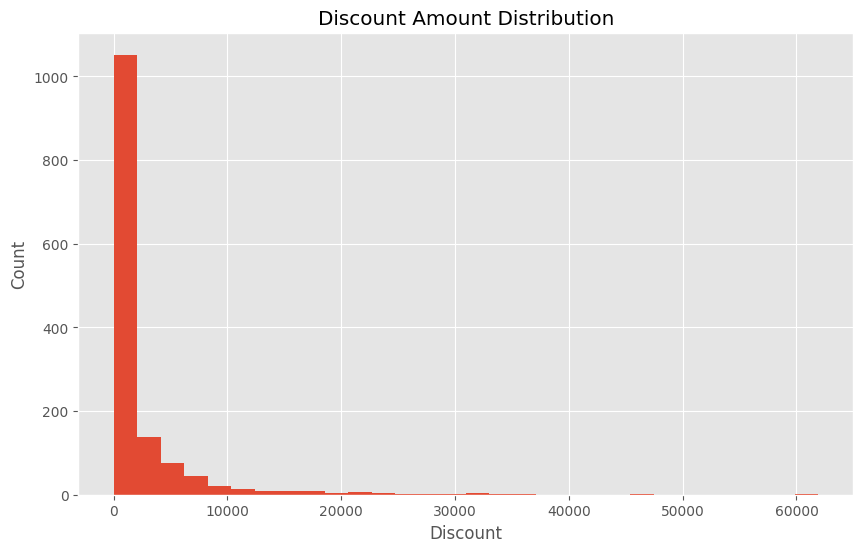

In [23]:
plt.figure(figsize=(10,6))

plt.hist(df["discount_amount"], bins=30)

plt.title("Discount Amount Distribution")

plt.xlabel("Discount")

plt.ylabel("Count")

plt.show()

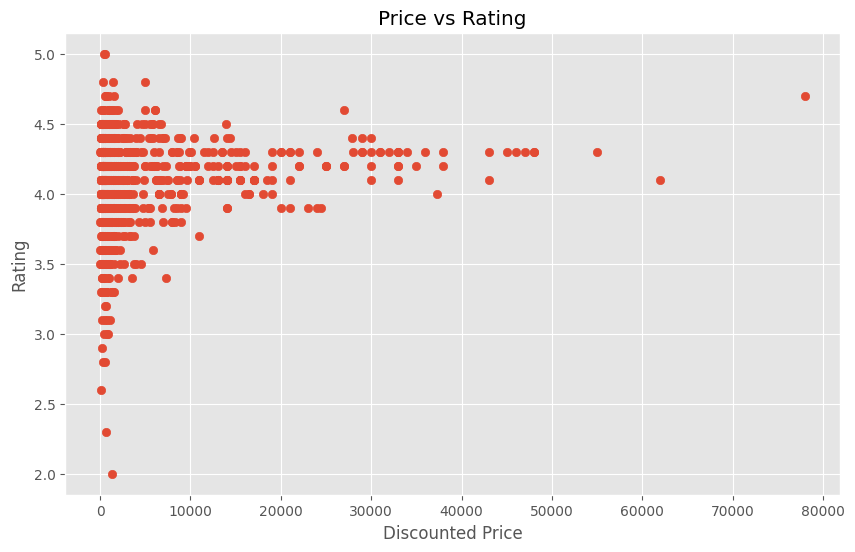

In [24]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["discounted_price"],
    df["rating"]
)

plt.xlabel("Discounted Price")

plt.ylabel("Rating")

plt.title("Price vs Rating")

plt.show()

In [25]:
plt.savefig("C:\\Users\\kunja\\Downloads\\Ecommerce_Vector_RAG\\outputs\\category_distribution.png")

<Figure size 1000x600 with 0 Axes>

In [26]:
plt.savefig("C:\\Users\\kunja\\Downloads\\Ecommerce_Vector_RAG\\outputs\\price_distribution.png")

<Figure size 1000x600 with 0 Axes>